In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import callbacks
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os
import warnings 
warnings.filterwarnings("ignore")

print("Done")

Done


In [2]:
# Define Constants
TRAIN_PATH = '/kaggle/input/datasets/laithjj/diabetic-foot-ulcer-dfu/DFU/Patches'
TEST_PATH = '/kaggle/input/datasets/laithjj/diabetic-foot-ulcer-dfu/DFU/TestSet'

BATCH_SIZE = 16
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
NUM_CLASSES = 2
EPOCHS = 12

In [3]:
print("TRAIN CONTENTS:")
for item in os.listdir(TRAIN_PATH):
    print(item)

print("\nTEST CONTENTS:")
for item in os.listdir(TEST_PATH):
    print(item)

TRAIN CONTENTS:
Normal(Healthy skin)
Abnormal(Ulcer)

TEST CONTENTS:
b4b2e1341a7bf627a58f6ac32212ed93.jpg
20.jpg
foot-ulcer-217x300.jpg
6.jpg
1167.jpg
images (2).jpg
images (4).jpg
diabetic-foot-ulcers-selective-focus-260nw-422934313.webp
feat_footulcer_cellul_1110_127752_127753.jpg
pt08cover4_0.jpg
images (13).jpg
5.jpg
wart-verrucas-plantar-fasciitis-on-260nw-1041891454.webp
8.jpg
images (9).jpg
images (22).jpg
0cbt67mm0fr01.jpg
foot-ulcer-pic (1).png
30.jpg
images (5).jpg
38.jpg
4 (2).jpg
calluses.jpg
1 .jpg
10.jpg
0.jpg
C0365633-Diabetic_Heel_Ulcer.jpg
images (19).jpg
222748d9f97a36c08da91dc46f6f5200.jpg
diabetische.jpg
46683AFD00000578-5088439-image-a-7_1510827626291.jpg
7527tn.jpg
2854.fig.1.png
images (10).jpg
images (23).jpg
images (6).jpg
pt1114diabetes_1.png
diabetic-foot-ulcer (1).jpg
ulcers (1).jpg
ulcers_before.jpg
tungiasis-3.jpg
9.jpg
Seed-Corn-under-Ball-of-Foot.jpg
37.jpg
1.jpg
images (25).jpg
images (16).jpg
pre-ulceration.jpg
diabetic-foot-ulcer_opt.jpg
corns2.gif
im

In [4]:
# Define class paths and collect image filenames

import os
from PIL import Image
import matplotlib.pyplot as plt

normal_path = os.path.join(TRAIN_PATH, "Normal(Healthy skin)")
abnormal_path = os.path.join(TRAIN_PATH, "Abnormal(Ulcer)")

normal_images = [
    f for f in os.listdir(normal_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

abnormal_images = [
    f for f in os.listdir(abnormal_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Normal images:", len(normal_images))
print("Abnormal images:", len(abnormal_images))

Normal images: 543
Abnormal images: 512


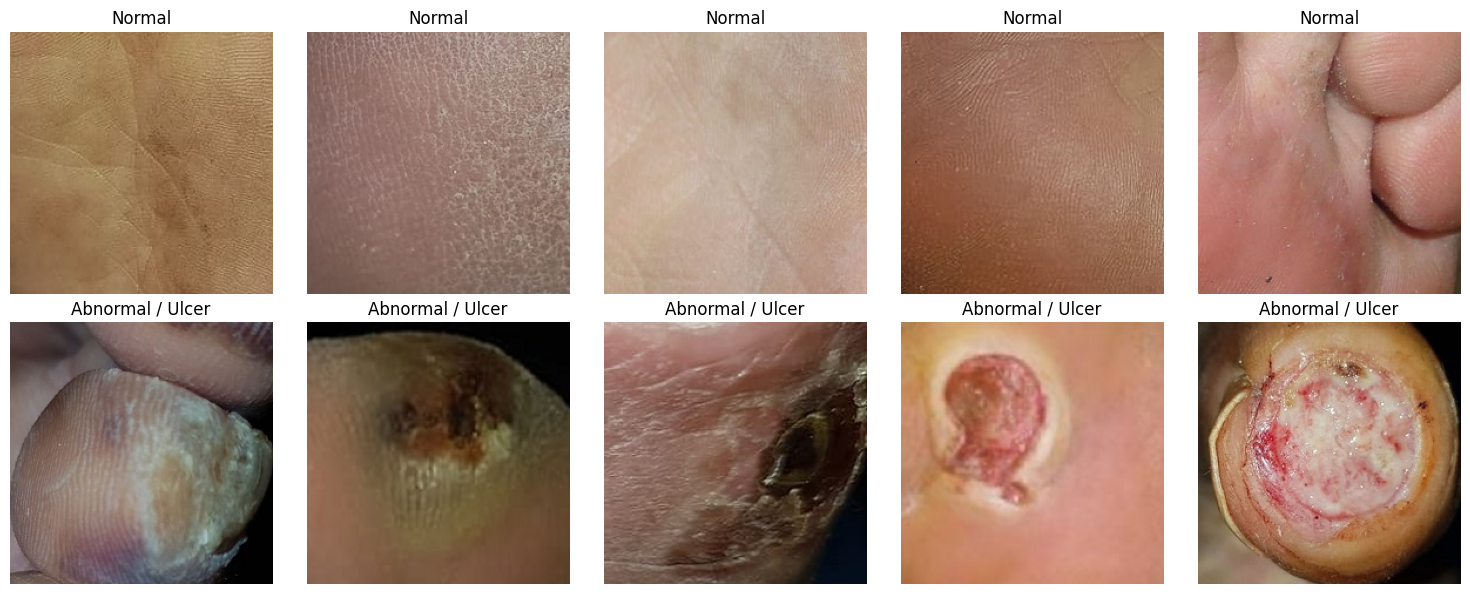

In [5]:
# Display sample images from both classes

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Normal samples
for i, filename in enumerate(normal_images[:5]):
    img = Image.open(os.path.join(normal_path, filename))
    axes[0, i].imshow(img)
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

# Abnormal samples
for i, filename in enumerate(abnormal_images[:5]):
    img = Image.open(os.path.join(abnormal_path, filename))
    axes[1, i].imshow(img)
    axes[1, i].set_title("Abnormal / Ulcer")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Class names:", train_ds.class_names)

Found 1055 files belonging to 2 classes.
Using 844 files for training.
Found 1055 files belonging to 2 classes.
Using 211 files for validation.
Class names: ['Abnormal(Ulcer)', 'Normal(Healthy skin)']


2026-08-09 05:23:43.992491: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
from collections import Counter

train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy().flatten())

val_labels = []
for _, labels in val_ds:
    val_labels.extend(labels.numpy().flatten())

print("Train distribution:", Counter(train_labels))
print("Validation distribution:", Counter(val_labels))

Train distribution: Counter({np.float32(1.0): 429, np.float32(0.0): 415})
Validation distribution: Counter({np.float32(1.0): 114, np.float32(0.0): 97})


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(500, seed=42).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),

    # Normalize pixels
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Replace Flatten with GlobalAveragePooling
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Binary classification
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/kaggle/working/best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.4941 - loss: 0.6921 - precision: 0.5050 - recall: 0.3132
Epoch 1: val_loss improved from None to 0.58485, saving model to /kaggle/working/best_cnn_model.keras

Epoch 1: finished saving model to /kaggle/working/best_cnn_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 858ms/step - accuracy: 0.5628 - loss: 0.6646 - precision: 0.6456 - recall: 0.3100 - val_accuracy: 0.8341 - val_loss: 0.5848 - val_precision: 0.7842 - val_recall: 0.9561
Epoch 2/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.8251 - loss: 0.4739 - precision: 0.8356 - recall: 0.8141
Epoch 2: val_loss improved from 0.58485 to 0.48187, saving model to /kaggle/working/best_cnn_model.keras

Epoch 2: finished saving model to /kaggle/working/best_cnn_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 841ms/step - accuracy: 0.8235 - loss: 0.4527 - precision: 0.7954 - recall: 0.8788 - val_accuracy: 0.8294 - val_loss: 0.4819 - val_precision: 0.7786 - val_recall: 0.9561
Epo

In [14]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

print("Class names:", val_ds.class_names)

Found 1055 files belonging to 2 classes.
Using 211 files for validation.
Class names: ['Abnormal(Ulcer)', 'Normal(Healthy skin)']


In [15]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_true = []
y_prob = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Convert probabilities to class predictions
y_pred = (y_prob >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Abnormal (Ulcer)",
        "Normal (Healthy skin)"
    ]
))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

auc_score = roc_auc_score(y_true, y_prob)

print(f"\nROC-AUC: {auc_score:.4f}")

Classification Report:
                       precision    recall  f1-score   support

     Abnormal (Ulcer)       0.90      0.87      0.88        97
Normal (Healthy skin)       0.89      0.92      0.91       114

             accuracy                           0.90       211
            macro avg       0.90      0.89      0.89       211
         weighted avg       0.90      0.90      0.90       211

Confusion Matrix:
[[ 84  13]
 [  9 105]]

ROC-AUC: 0.9570


In [16]:
from collections import Counter

labels_check = []

for _, labels in val_ds:
    labels_check.extend(labels.numpy().flatten())

print("Validation distribution:", Counter(labels_check))

Validation distribution: Counter({np.float32(1.0): 114, np.float32(0.0): 97})


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the pretrained layers
base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)),

    # MobileNetV2 preprocessing
    layers.Rescaling(1./127.5, offset=-1),

    # Pretrained feature extractor
    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Binary classification
    layers.Dense(1, activation='sigmoid')
])

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Train the model with early stopping and best-model checkpoint

transfer_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_mobilenetv2_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

transfer_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[
        transfer_checkpoint,
        transfer_early_stopping
    ]
)

Epoch 1/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8307 - loss: 0.4002 - precision: 0.8469 - recall: 0.8036
Epoch 1: val_loss improved from None to 0.06375, saving model to /kaggle/working/best_mobilenetv2_model.keras

Epoch 1: finished saving model to /kaggle/working/best_mobilenetv2_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 429ms/step - accuracy: 0.9076 - loss: 0.2541 - precision: 0.9149 - recall: 0.9021 - val_accuracy: 1.0000 - val_loss: 0.0637 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9782 - loss: 0.0801 - precision: 0.9814 - recall: 0.9757
Epoch 2: val_loss improved from 0.06375 to 0.03383, saving model to /kaggle/working/best_mobilenetv2_model.keras

Epoch 2: finished saving model to /kaggle/working/best_mobilenetv2_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 40s 415ms/step - accuracy: 0.9739 - loss: 0.0819 - precision: 0.9766 - recall: 0.9720 - val_accuracy: 0.9953 - val_loss: 0.0338 - val_precision:

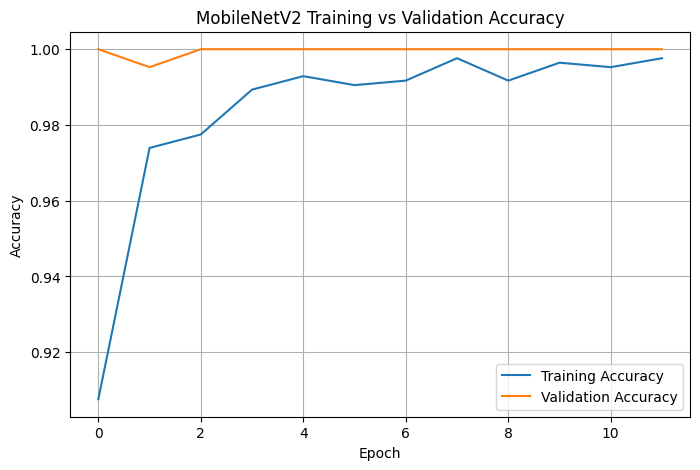

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

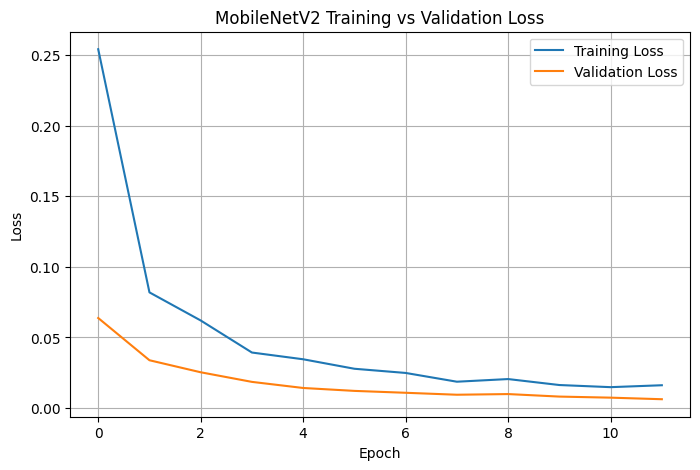

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Load the best saved MobileNetV2 model

best_model = tf.keras.models.load_model(
    "/kaggle/working/best_mobilenetv2_model.keras"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [22]:
# Evaluate the best model on the validation dataset

val_results = best_model.evaluate(
    val_ds,
    verbose=1
)

print("\nValidation Results:")
for name, value in zip(best_model.metrics_names, val_results):
    print(f"{name}: {value:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 295ms/step - accuracy: 1.0000 - loss: 0.0062 - precision: 1.0000 - recall: 1.0000

Validation Results:
loss: 0.0062
compile_metrics: 1.0000


In [23]:
y_true = []
y_prob = []

for images, labels in val_ds:
    predictions = best_model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_prob.extend(predictions.ravel())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Convert probabilities to binary predictions
y_pred = (y_prob >= 0.5).astype(int)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)

True labels: (211, 1)
Predictions: (211,)


In [24]:
class_names = [
    "Abnormal (Ulcer)",
    "Normal (Healthy skin)"
]

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2
    )
)

Classification Report:

                       precision    recall  f1-score   support

     Abnormal (Ulcer)       1.00      1.00      1.00        97
Normal (Healthy skin)       1.00      1.00      1.00       114

             accuracy                           1.00       211
            macro avg       1.00      1.00      1.00       211
         weighted avg       1.00      1.00      1.00       211



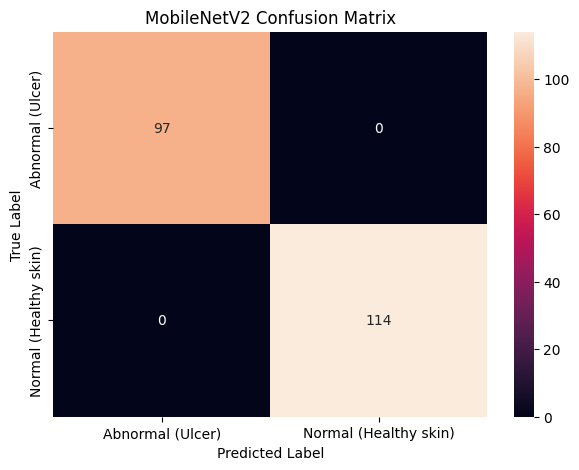

In [25]:

import seaborn as sns


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

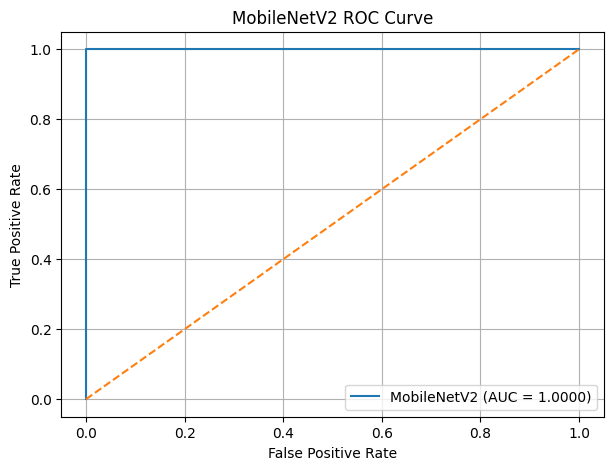

ROC-AUC: 1.0000


In [26]:
# Plot ROC Curve and calculate ROC-AUC

from sklearn.metrics import roc_curve, roc_auc_score

roc_auc = roc_auc_score(y_true, y_prob)

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"MobileNetV2 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

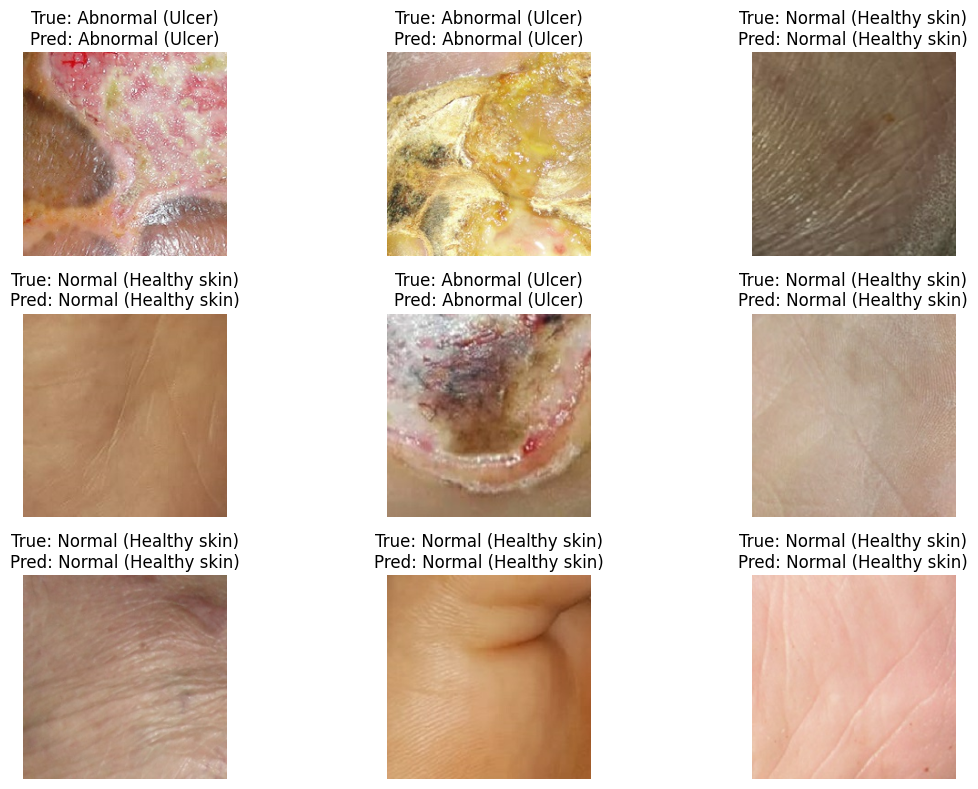

In [27]:
# Visualize sample validation images with model predictions

plt.figure(figsize=(12, 8))

for images, labels in val_ds.take(1):

    predictions = best_model.predict(images, verbose=0).ravel()

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        # Convert pixel values from 0-255 to 0-1 for visualization
        image = images[i].numpy() / 255.0

        plt.imshow(image)

        true_label = int(labels[i].numpy())
        predicted_label = int(predictions[i] >= 0.5)

        plt.title(
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[predicted_label]}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Save the final trained MobileNetV2 model

final_model_path = "/kaggle/working/DFU_MobileNetV2_Final.keras"

best_model.save(final_model_path)

print("Model saved successfully!")
print(f"Saved to: {final_model_path}")

Model saved successfully!
Saved to: /kaggle/working/DFU_MobileNetV2_Final.keras


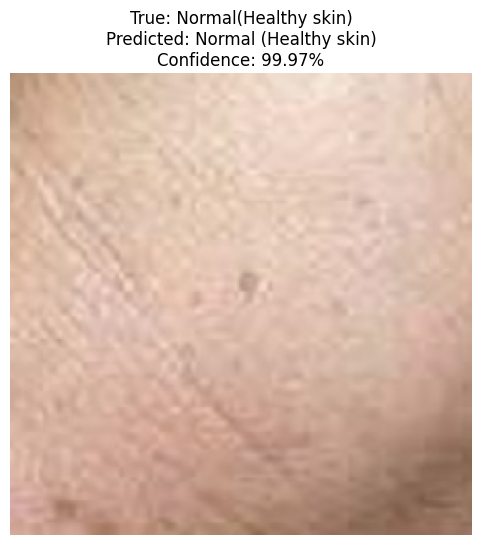

True Class: Normal(Healthy skin)
Predicted Class: Normal (Healthy skin)
Confidence: 99.97%


In [29]:
# Random Image Selection + Model Prediction

import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import load_img, img_to_array

# Get all image paths from validation dataset
image_paths = val_ds.file_paths

# Select a random image
random_image_path = random.choice(image_paths)

# Load image
img = load_img(
    random_image_path,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH)
)

# Convert image to array
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = transfer_model.predict(img_array, verbose=0)[0][0]

# Convert prediction to class
predicted_class = 1 if prediction >= 0.5 else 0

# Get true class from folder name
true_class_name = random_image_path.split("/")[-2]

# Class mapping
class_names = ['Abnormal (Ulcer)', 'Normal (Healthy skin)']

# Calculate confidence
confidence = prediction if predicted_class == 1 else 1 - prediction

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"True: {true_class_name}\n"
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2%}"
)

plt.show()

print(f"True Class: {true_class_name}")
print(f"Predicted Class: {class_names[predicted_class]}")
print(f"Confidence: {confidence:.2%}")